In [38]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score

In [39]:
import glob
# Specify the path and pattern to load multiple files
file_paths = glob.glob("/data/wsd02/maleen_data/MJ03F*.Data")  # adjust path as needed

# Read and concatenate all files
df_list = []
for path in file_paths:
    temp_df = pd.read_csv(path, header=None, names=["time", "rawpsi", "depth", "temp"])
    temp_df['time'] = pd.to_datetime(temp_df['time'])
    df_list.append(temp_df)

# Combine into one DataFrame
cp = pd.concat(df_list, ignore_index=True).sort_values('time')

cp['time'] = pd.to_datetime(cp['time'])
cp['p']= (cp['depth']/0.67)
cp = cp.reset_index()
cp = cp.drop(columns=["index"])

In [40]:
cp

,time,rawpsi,depth,temp,p
0,2016-01-01 00:00:00,2256.901400,1511.627900,2.777386,2256.161045
1,2016-01-01 00:00:15,2256.896600,1511.624600,2.777327,2256.156119
2,2016-01-01 00:00:30,2256.891800,1511.621200,2.777256,2256.151045
3,2016-01-01 00:00:45,2256.892700,1511.621700,2.777218,2256.151791
4,2016-01-01 00:01:00,2256.893700,1511.622100,2.777155,2256.152388
...,...,...,...,...,...
19357222,2025-09-15 00:27:00,2254.769943,1509.714562,2.784791,2253.305316
19357223,2025-09-15 00:27:15,2254.770865,1509.714780,2.784802,2253.305641
19357224,2025-09-15 00:27:30,2254.771606,1509.714876,2.784792,2253.305785
19357225,2025-09-15 00:27:45,2254.774897,1509.716581,2.784804,2253.308330


In [41]:
import glob
# Specify the path and pattern to load multiple files
file_paths = glob.glob("/data/wsd02/maleen_data/MJ03E*.Data")  # adjust path as needed

# Read and concatenate all files
df_list = []
for path in file_paths:
    temp_df = pd.read_csv(path, header=None, names=["time", "rawpsi", "depth", "temp"])
    temp_df['time'] = pd.to_datetime(temp_df['time'])
    df_list.append(temp_df)

# Combine into one DataFrame
ep = pd.concat(df_list, ignore_index=True).sort_values('time')

ep['time'] = pd.to_datetime(ep['time'])
ep['p']= (ep['depth']/0.67)

In [42]:
import glob
# Specify the path and pattern to load multiple files
file_paths = glob.glob("/data/wsd02/maleen_data/MJ03B*.Data")  # adjust path as needed

# Read and concatenate all files
df_list = []
for path in file_paths:
    temp_df = pd.read_csv(path, header=None, names=["time", "rawpsi", "depth", "temp"])
    temp_df['time'] = pd.to_datetime(temp_df['time'])
    df_list.append(temp_df)

# Combine into one DataFrame
wp = pd.concat(df_list, ignore_index=True).sort_values('time')

wp['time'] = pd.to_datetime(wp['time'])
wp['p']= (wp['depth']/0.67)

In [43]:
wp

,time,rawpsi,depth,temp,p
0,2017-08-17 00:00:00,2276.793300,1525.148200,3.183673,2276.340597
1,2017-08-17 00:00:15,2276.790900,1525.145200,3.183974,2276.336119
2,2017-08-17 00:00:30,2276.793100,1525.145300,3.184278,2276.336269
3,2017-08-17 00:00:45,2276.804700,1525.151600,3.184563,2276.345672
4,2017-08-17 00:01:00,2276.800900,1525.147600,3.184851,2276.339701
...,...,...,...,...,...
15919014,2025-09-19 00:27:00,2274.546082,1524.354935,3.142856,2275.156619
15919015,2025-09-19 00:27:15,2274.546037,1524.354695,3.142845,2275.156261
15919016,2025-09-19 00:27:30,2274.546894,1524.355059,3.142833,2275.156805
15919017,2025-09-19 00:27:45,2274.548670,1524.356029,3.142823,2275.158252


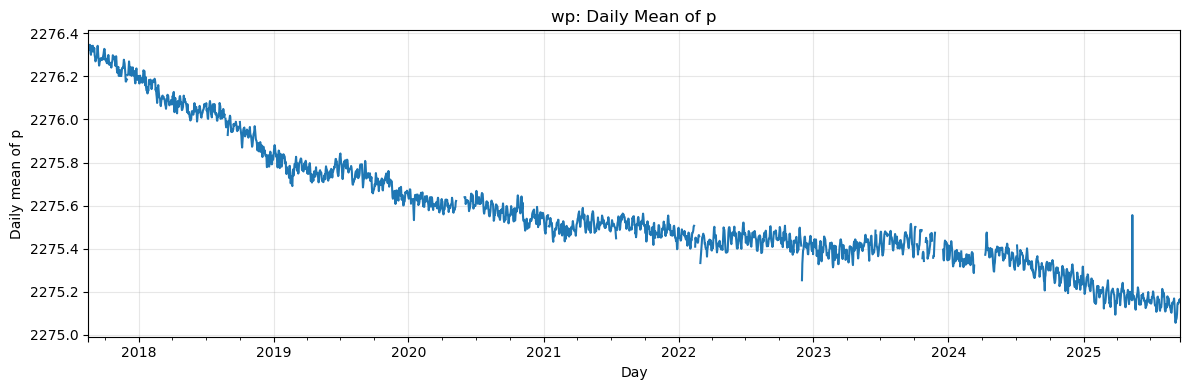

In [60]:
import pandas as pd
import matplotlib.pyplot as plt

# Work on a copy
df = wp.copy()

# 1) Ensure time is datetime (and strip tz if present)
df["time"] = pd.to_datetime(df["time"], errors="coerce", utc=True)
df["time"] = df["time"].dt.tz_convert(None)

# 2) Daily mean of column `p`
daily = (
    df.set_index("time")["p"]
      .resample("1D").mean()
      .rename("p_daily_mean")
      .to_frame()
)

# 3) Plot
ax = daily.plot(figsize=(12, 4), legend=False)
ax.set_xlabel("Day")
ax.set_ylabel("Daily mean of p")
ax.set_title("wp: Daily Mean of p")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# (Optional) Save for later
# daily.reset_index().to_csv("wp_p_daily_mean.csv", index=False)


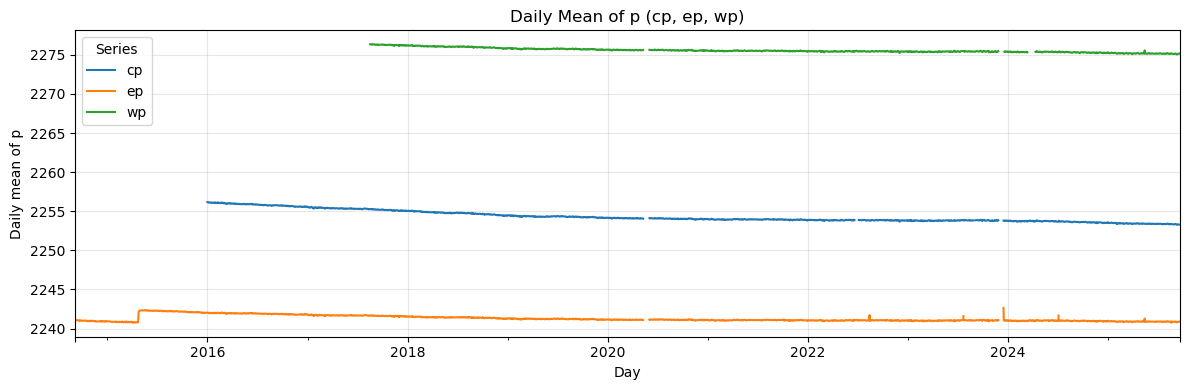

In [66]:
import pandas as pd
import matplotlib.pyplot as plt

def daily_mean_p(df, label):
    x = df.copy()

    # --- get a DatetimeIndex called idx (UTC-aware), regardless of layout ---
    if "time" in x.columns:                        # time provided as a column
        ts = pd.to_datetime(x.pop("time"), errors="coerce", utc=True)  # Series
        idx = pd.DatetimeIndex(ts)                 # make it an index object
    else:                                          # time already an index (or not)
        idx = pd.to_datetime(x.index, errors="coerce", utc=True)
        idx = pd.DatetimeIndex(idx)

    # --- drop timezone to make all three compatible for concat ---
    if idx.tz is not None:
        idx = idx.tz_convert(None)

    # set index and clean
    x.index = idx
    x.index.name = "time"
    x = x[~x.index.isna()]

    # --- daily mean of column p ---
    return x["p"].resample("1D").mean().rename(label)

# Build series for each dataframe
cp_daily = daily_mean_p(cp, "cp")
ep_daily = daily_mean_p(ep, "ep")
wp_daily = daily_mean_p(wp, "wp")

# Align on calendar days (optionally window with .loc["2023-09-01":"2025-09-01"])
daily = pd.concat([cp_daily, ep_daily, wp_daily], axis=1)

# Plot
fig, ax = plt.subplots(figsize=(12, 4))
daily.plot(ax=ax, linewidth=1.5)
ax.set_title("Daily Mean of p (cp, ep, wp)")
ax.set_xlabel("Day")
ax.set_ylabel("Daily mean of p")
ax.grid(True, alpha=0.3)
ax.legend(title="Series")
plt.tight_layout()
plt.show()


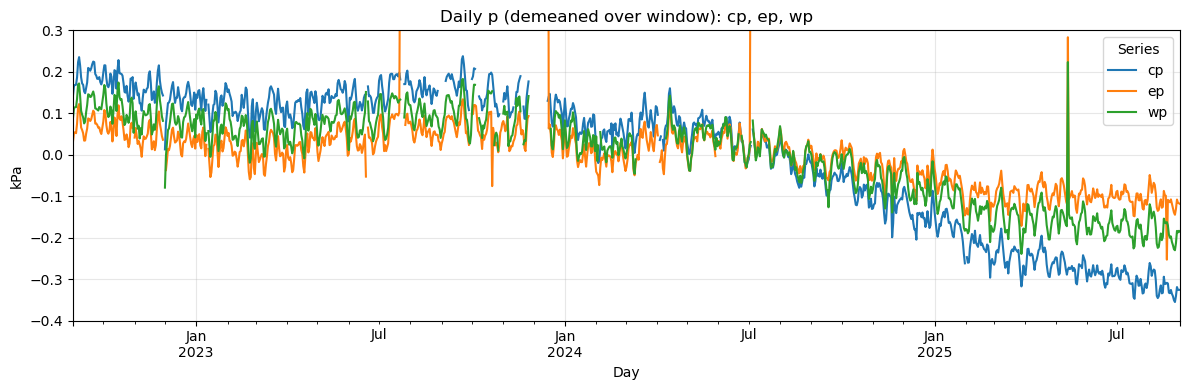

In [73]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Window
start = pd.Timestamp("2022-09-01")
end   = pd.Timestamp("2025-09-01")
win = daily.loc[start:end].copy()            # daily has columns: cp, ep, wp

# Demean (subtract each series mean over the window)
demeaned = win - win.mean()

# Symmetric y-limits around 0 (10% padding)
max_abs = np.nanmax(np.abs(demeaned.values))
ylims = (-1.1 * max_abs, 1.1 * max_abs)

# Plot
fig, ax = plt.subplots(figsize=(12, 4))
demeaned.plot(ax=ax, linewidth=1.5)
ax.set_title("Daily p (demeaned over window): cp, ep, wp")
ax.set_xlabel("Day")
ax.set_ylabel("kPa")
ax.grid(True, alpha=0.3)
ax.legend(title="Series")
ax.set_ylim(*ylims)                # <-- auto y-limit

# Optional: set manual limits instead (example)
ax.set_ylim(-0.4, 0.3)

plt.tight_layout()
plt.show()


In [123]:
daily

,cp,ep,wp
time,,,
2014-09-04,NaN,2241.080631,NaN
2014-09-05,NaN,2241.090592,NaN
2014-09-06,NaN,2241.065928,NaN
2014-09-07,NaN,2241.038339,NaN
2014-09-08,NaN,2241.054003,NaN
...,...,...,...
2025-09-15,2253.307859,2240.855099,2275.145810
2025-09-16,NaN,2240.886153,2275.155001
2025-09-17,NaN,2240.899127,2275.162286


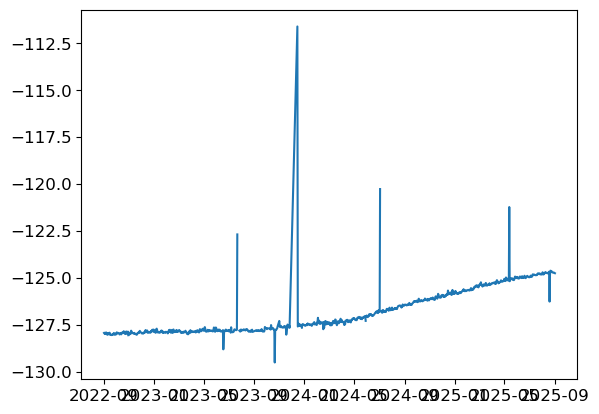

In [115]:
plt.plot(diff['cp_minus_ep']*9.998)
plt.ylims(-0.3, 0.2)


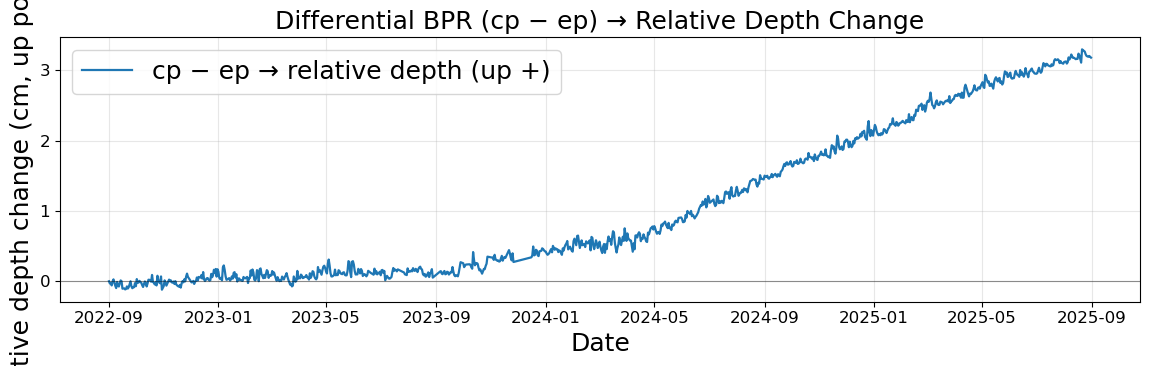

In [125]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ---------------- config ----------------
CM_PER_KPA = 9.94                    # your convention
start = pd.Timestamp("2022-09-01")
end   = pd.Timestamp("2025-09-01")
hampel_window = 15                   # days (rolling window half-width ≈ window//2)
hampel_sigma  = 3.0                  # outlier threshold in MAD units

# ---------------- prep ----------------
df = daily.copy()
if not pd.api.types.is_datetime64_any_dtype(df.index):
    df.index = pd.to_datetime(df.index, errors="coerce")
df = df.sort_index()

# restrict to window
df = df.loc[(df.index >= start) & (df.index < end)].copy()

# ---------------- differential -> depth (up positive) ----------------
df["cp_minus_ep_kPa"] = df["cp"] - df["ep"]
df["depth_change_cm_raw"] = -CM_PER_KPA * df["cp_minus_ep_kPa"]   # up = positive

# make it relative (start at 0 in the time window)
first_valid = df["depth_change_cm_raw"].dropna().iloc[0]
df["rel_depth_cm"] = df["depth_change_cm_raw"] - first_valid

# ---------------- Hampel outlier removal ----------------
def hampel_filter(s, window, n_sigma):
    # rolling median and MAD
    med = s.rolling(window, center=True, min_periods=1).median()
    mad = (s - med).abs().rolling(window, center=True, min_periods=1).median()
    # consistent MAD -> sigma scale factor ~1.4826 (for normal dist)
    thresh = n_sigma * 1.4826 * mad
    mask_outlier = (s - med).abs() > thresh
    s_filt = s.mask(mask_outlier)  # set outliers to NaN
    return s_filt, mask_outlier

df["rel_depth_cm_filt"], _ = hampel_filter(df["rel_depth_cm"], hampel_window, hampel_sigma)

# interpolate gaps introduced by outlier removal (time-aware if index is datetime)
df["rel_depth_cm_filt"] = df["rel_depth_cm_filt"].interpolate(method="time").bfill().ffill()

# ---------------- plot ----------------
plt.figure(figsize=(12,4))
plt.plot(df.index, df["rel_depth_cm_filt"], lw=1.6, label="cp − ep → relative depth (up +)")
plt.axhline(0, color="k", lw=0.8, alpha=0.4)
plt.grid(True, alpha=0.3)
plt.xlabel("Date")
plt.ylabel("Relative depth change (cm, up positive)")
plt.title("Differential BPR (cp − ep) → Relative Depth Change")
plt.legend()
plt.tight_layout()
plt.show()


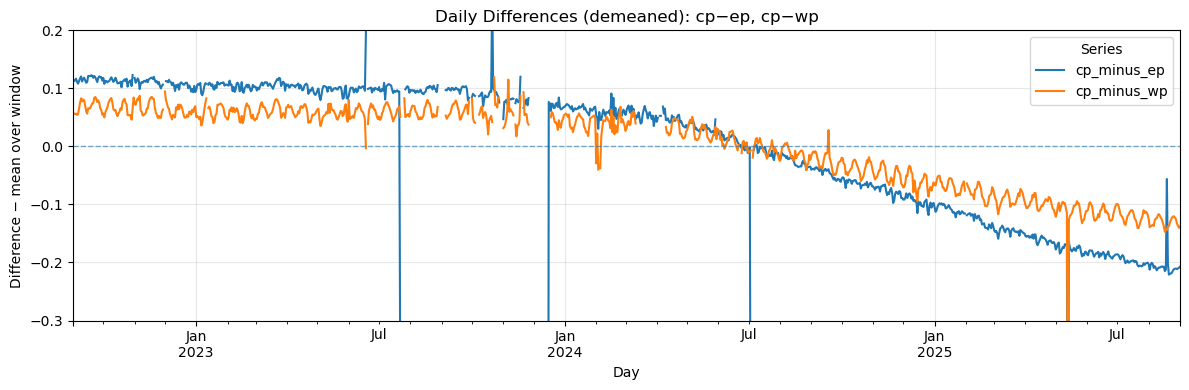

In [78]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

start = pd.Timestamp("2022-09-01")
end   = pd.Timestamp("2025-09-01")

# 1) Build daily differences in the window
diff = pd.DataFrame({
    "cp_minus_ep": daily["cp"] - daily["ep"],
    "cp_minus_wp": daily["cp"] - daily["wp"],
}).loc[start:end]

# 2) Demean each series (subtract its own mean over the window)
demeaned = diff.subtract(diff.mean(), axis=1)

# 3) Symmetric y-limits around zero (10% padding)
max_abs = np.nanmax(np.abs(demeaned.values))
ylims = (-0.3, 0.2)

# 4) Plot
fig, ax = plt.subplots(figsize=(12, 4))
demeaned.plot(ax=ax, linewidth=1.5)
ax.set_title("Daily Differences (demeaned): cp−ep, cp−wp")
ax.set_xlabel("Day")
ax.set_ylabel("Difference − mean over window")
ax.grid(True, alpha=0.3)
ax.legend(title="Series")
ax.set_ylim(*ylims)
plt.tight_layout()
plt.show()


Conversion factor ≈ 0.09948 m per kPa (9.95 cm per kPa)


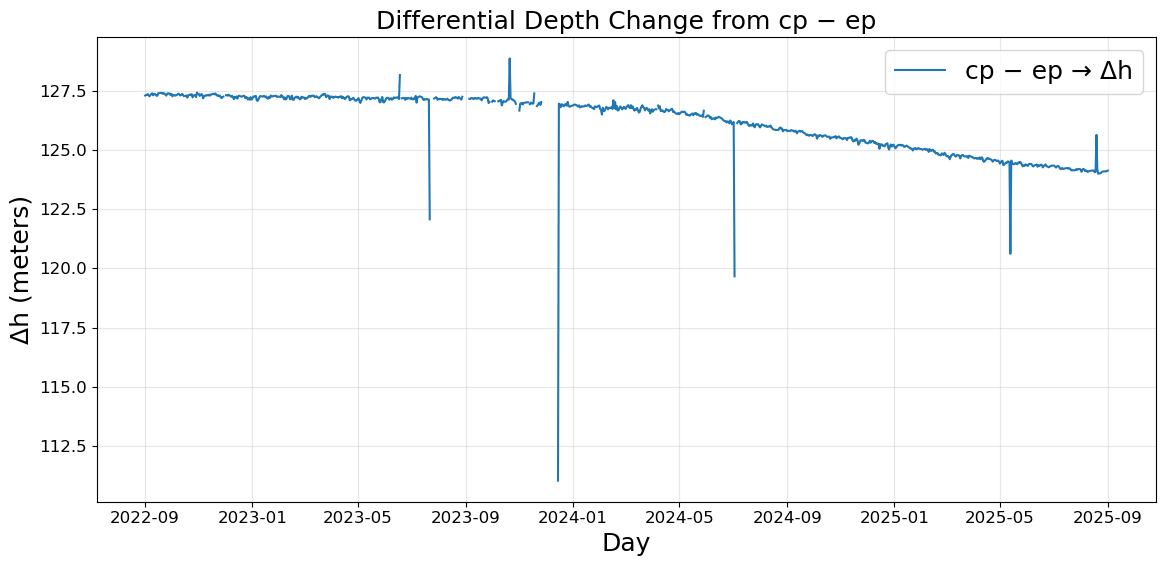

In [104]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- constants (tweak if you have in-situ rho) ---
rho = 1025.0        # kg/m^3 (seawater)
g   = 9.80665       # m/s^2
kPa_to_Pa = 1000.0

# Window
start = pd.Timestamp("2022-09-01")
end   = pd.Timestamp("2025-09-01")

# cp-ep in kPa from your 'daily' dataframe
diff_kpa = (daily["cp"] - daily["ep"]).loc[start:end]

# Convert to depth change: Δh [m] = ΔP [Pa] / (rho*g)
dh_m  = (diff_kpa * kPa_to_Pa) / (rho * g)
dh_cm = dh_m * 100.0

print(f"Conversion factor ≈ {kPa_to_Pa/(rho*g):.5f} m per kPa "
      f"({100*kPa_to_Pa/(rho*g):.2f} cm per kPa)")

# Plot (meters)
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(dh_m.index, dh_m.values, lw=1.5, label="cp − ep → Δh")
ax.set_title("Differential Depth Change from cp − ep")
ax.set_xlabel("Day")
ax.set_ylabel("Δh (meters)")
ax.grid(True, alpha=0.3)
ax.legend()

# Optional: manual y-limits
ax.set_ylim(1.29, 1.2)  # meters

plt.tight_layout()
plt.show()




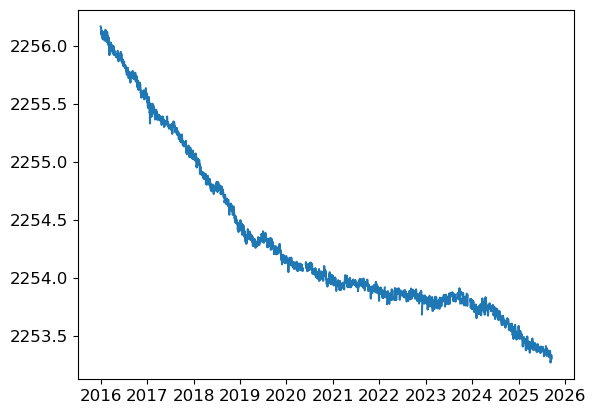

In [106]:
plt.plot(daily["cp"])

Outliers removed: {'cp_minus_ep': 19, 'cp_minus_wp': 8}


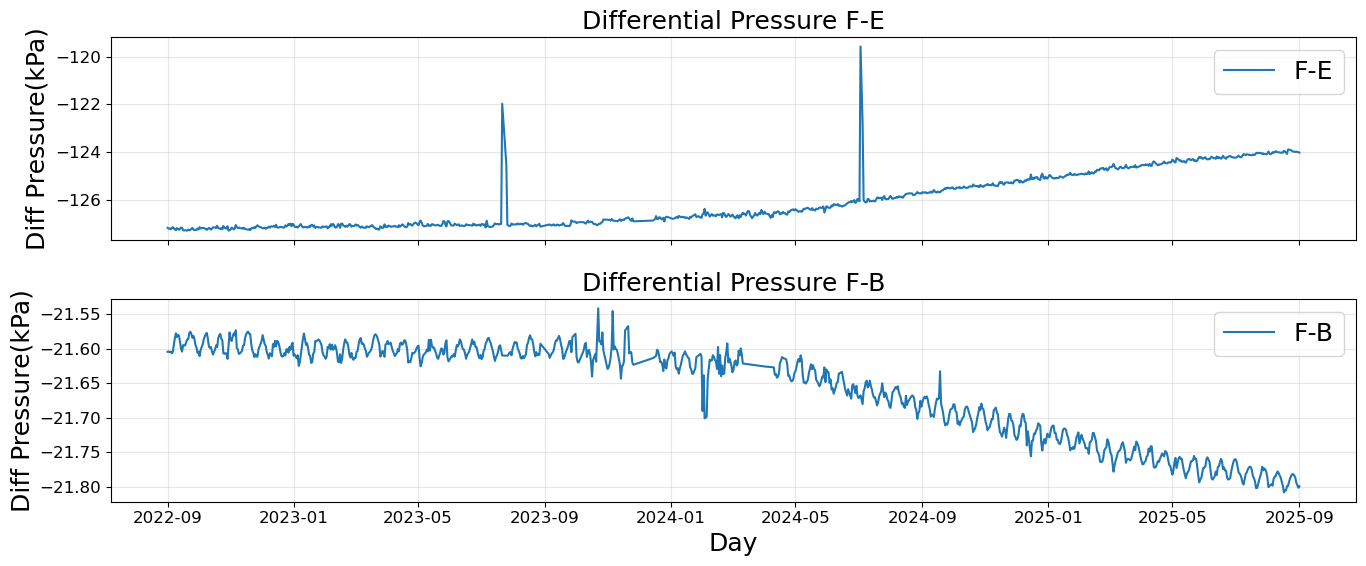

In [107]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- 1) Build daily differences over your window ---
start = pd.Timestamp("2022-09-01")
end   = pd.Timestamp("2025-09-01")

diff = pd.DataFrame({
    "cp_minus_ep": daily["cp"] - daily["ep"],
    "cp_minus_wp": daily["cp"] - daily["wp"],
}).loc[start:end].dropna(how="all")

# --- 2) Robust Hampel filter to remove outliers ---
def hampel_filter(series, window=15, n_sigmas=3.5, replace_with="nan"):
    """
    Hampel filter using rolling median and MAD.
    replace_with: 'nan' to remove, 'median' to replace with local median.
    """
    s = series.copy()
    med = s.rolling(window, center=True, min_periods=max(3, window//2)).median()
    mad = s.rolling(window, center=True, min_periods=max(3, window//2)) \
           .apply(lambda x: np.median(np.abs(x - np.median(x))), raw=True)

    sigma = 1.4826 * mad  # robust std
    outliers = (s - med).abs() > (n_sigmas * sigma)

    if replace_with == "median":
        s[outliers] = med[outliers]
    else:  # 'nan'
        s[outliers] = np.nan
    return s, outliers

clean = pd.DataFrame(index=diff.index)
outlier_masks = {}

# tune window and threshold if needed (daily data -> 15–31 is common)
win = 15
thr = 3.5

for col in diff.columns:
    clean[col], outlier_masks[col] = hampel_filter(diff[col], window=win, n_sigmas=thr, replace_with="nan")
    # optional: interpolate across removed outliers for nicer lines (comment out if undesired)
    clean[col] = clean[col].interpolate(limit_direction="both")

# (Optional) quick count of removed points
removed_counts = {c: int(outlier_masks[c].sum()) for c in outlier_masks}
print("Outliers removed:", removed_counts)

# --- 3) Replot in two subfigures (no demeaning); units in kPa ---
fig, axs = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

import matplotlib.pyplot as plt
plt.rcParams.update({
    "font.size": 18,           # base
    "axes.titlesize": 18,
    "axes.labelsize": 18,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 18,
})

axs[0].plot(clean.index, clean["cp_minus_ep"]*-9.94, lw=1.5, label="F-E")
axs[0].set_title("Differential Pressure F-E")
axs[0].set_ylabel("Diff Pressure(kPa)")
#axs[0].set_ylim(12.4, 12.83)   # cp − ep, kPa
axs[0].grid(True, alpha=0.3)
axs[0].legend()

axs[1].plot(clean.index, clean["cp_minus_wp"], lw=1.5, label="F-B")
axs[1].set_title("Differential Pressure F-B")
axs[1].set_xlabel("Day")
axs[1].set_ylabel("Diff Pressure(kPa)")
axs[1].grid(True, alpha=0.3)
axs[1].legend()

plt.tight_layout()
plt.show()


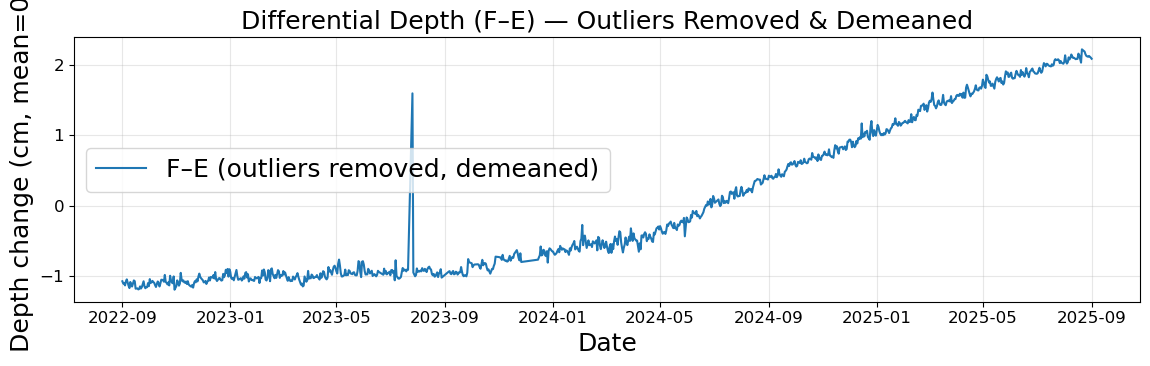

In [109]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.plot(diff['cp_minus_ep']*-9.998)
# 1) Prep the series
CM_PER_kPa = 9.948  # depth cm per kPa (ρ=1025 kg/m³, g=9.80665)
series = clean["cp_minus_ep"].astype(float).dropna()

# ensure datetime index
idx = clean.index
if not isinstance(idx, pd.DatetimeIndex):
    idx = pd.to_datetime(idx, errors="coerce")
series.index = idx
series = series.sort_index().dropna()

# convert kPa -> cm (positive = deeper; pressure increase -> positive)
y_cm = -series * CM_PER_kPa

# 2) Robust outlier detection via MAD
med = y_cm.median()
mad = (np.abs(y_cm - med)).median()
# guard against MAD=0
mad = mad if mad > 0 else (np.abs(y_cm - med)).mean()

# mark outliers (tunable threshold: 5×MAD)
thr = 5.0 * mad
mask_out = np.abs(y_cm - med) > thr
y_clean = y_cm.copy()
y_clean[mask_out] = np.nan

# optional: drop isolated NaNs at edges conservatively
# y_clean = y_clean.loc[y_clean.first_valid_index(): y_clean.last_valid_index()]

# 3) Interpolate over outliers, then demean
y_filled = y_clean.interpolate(method="time", limit_direction="both")
y_demeaned = y_filled - y_filled.mean()

# 4) Plot (single axes)
plt.figure(figsize=(12, 4))
plt.plot(y_demeaned.index, y_demeaned.values, lw=1.5, label="F–E (outliers removed, demeaned)")
plt.title("Differential Depth (F–E) — Outliers Removed & Demeaned")
plt.ylabel("Depth change (cm, mean=0)")
plt.xlabel("Date")
plt.grid(True, alpha=0.3)
plt.legend()
# Optional y-limits:
# plt.ylim(-50, 50)
plt.tight_layout()
plt.show()


In [46]:
def seven_day_stats(df, start, end, cols=('p', 'depth')):
    df = df.copy()
    df['time'] = pd.to_datetime(df['time'])
    df = df.set_index('time').sort_index()

    start = pd.to_datetime(start)
    end   = pd.to_datetime(end)

    # ── NEW: expand date-only 'end' to 23:59:59 ────────────────────────────────
    if end.time() == pd.Timestamp(0).time():          # means hour:min:sec == 00:00:00
        end += pd.Timedelta(days=1) - pd.Timedelta(seconds=1)

    first  = df.loc[start : start + pd.Timedelta(days=30)][list(cols)].mean()
    last   = df.loc[end   - pd.Timedelta(days=30) : end][list(cols)].mean()

    return pd.DataFrame(
        {'start_mean': first, 'end_mean': last, 'delta': last - first}
    )


In [47]:
stats_cp = seven_day_stats(cp, "2017-08-17", "2020-06-01")
print(stats_cp)

        start_mean     end_mean     delta
p      2255.239366  2254.078914 -1.160453
depth  1511.010375  1510.232872 -0.777503


In [48]:
stats_ep = seven_day_stats(ep, "2017-08-17", "2020-06-01")
print(stats_ep)

        start_mean     end_mean     delta
p      2241.644744  2241.114035 -0.530709
depth  1501.901979  1501.546403 -0.355575


In [49]:
stats_wp = seven_day_stats(wp, "2017-08-17", "2020-06-01")
print(stats_wp)

        start_mean     end_mean     delta
p      2276.316010  2275.591733 -0.724276
depth  1525.131726  1524.646461 -0.485265


In [50]:
stats_cp = seven_day_stats(cp, "2022-06-01", "2024-09-01")
print(stats_cp)

        start_mean     end_mean     delta
p      2253.867045  2253.644991 -0.222053
depth  1510.090920  1509.942144 -0.148776


In [51]:
stats_ep = seven_day_stats(ep, "2022-06-01", "2024-09-01")
print(stats_ep)

        start_mean     end_mean     delta
p      2241.059822  2240.987676 -0.072146
depth  1501.510081  1501.461743 -0.048338


In [52]:
stats_wp = seven_day_stats(wp, "2022-06-01", "2024-09-01")
print(stats_wp)

        start_mean     end_mean     delta
p      2275.455423  2275.320794 -0.134629
depth  1524.555133  1524.464932 -0.090201


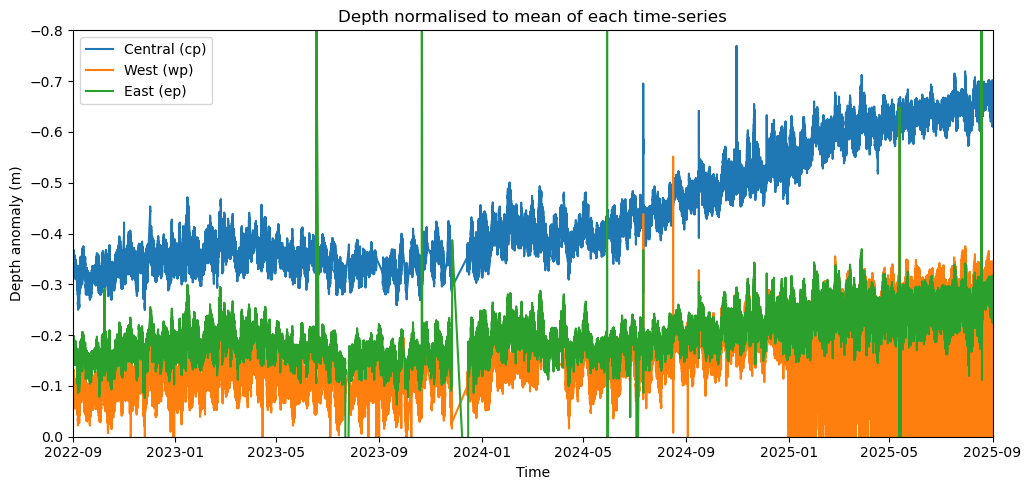

In [53]:
import pandas as pd
import matplotlib.pyplot as plt

def centre_on_mean(df, name):
    """
    Returns depth anomalies (m) after subtracting the *overall* mean depth
    of the DataFrame.
    """
    tmp = df.copy()

    # ensure a proper datetime index
    tmp['time'] = pd.to_datetime(tmp['time'])
    tmp = tmp.set_index('time').sort_index()

    mean_depth = tmp['depth'].mean()
    return (tmp['depth'] - mean_depth).rename(name)


# --- build centred series for each station -----------------------------------
cp_anom = centre_on_mean(cp, 'Central (cp)')
wp_anom = centre_on_mean(wp, 'West (wp)')
ep_anom = centre_on_mean(ep, 'East (ep)')

# --- plot --------------------------------------------------------------------
plt.figure(figsize=(10, 5))
for s in [cp_anom, wp_anom, ep_anom]:
    plt.plot(s.index, s, label=s.name)

plt.ylabel('Depth anomaly (m)')
plt.xlabel('Time')
plt.title('Depth normalised to mean of each time-series')
plt.legend()
plt.gca().invert_yaxis()   # optional: deeper = downward
plt.tight_layout()
start = pd.Timestamp("2022-09-01")
end   = pd.Timestamp("2025-09-01")
plt.ylim(0,-0.8)
plt.xlim(start, end) 
plt.show()


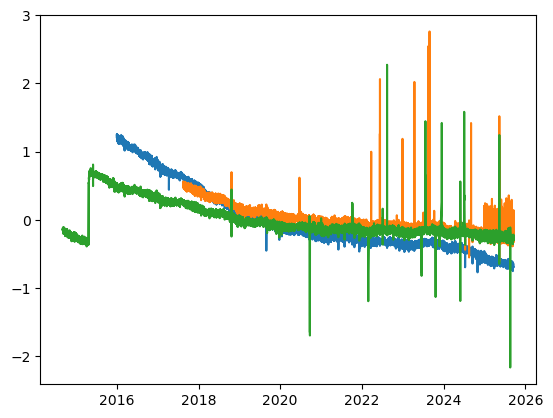

In [57]:
for s in [wp_anom]:
    plt.plot(s.index, s, label=s.name)

In [54]:
import pandas as pd
import numpy as np

def ensure_datetime_index(df, col='time'):
    """Make sure *df* is indexed by a DatetimeIndex called *time*."""
    if col in df.columns:                      # case 1 – still a column
        df[col] = pd.to_datetime(df[col])
        df.set_index(col, inplace=True)
    else:                                      # case 2 – already the index
        if not isinstance(df.index, pd.DatetimeIndex):
            df.index = pd.to_datetime(df.index)
    df.sort_index(inplace=True)                # keep it time-ordered
    return df

# --- 1.  guarantee proper indexing ---------------------------------
cp = ensure_datetime_index(cp)
ep = ensure_datetime_index(ep)

# --- 2.  differential pressure  (cp − ep) --------------------------
diff = (cp['p'] - ep['p']).to_frame(name='dP_cp_ep')

# --- 3.  7-day mean helper ----------------------------------------
def mean_7d(series, anchor):
    anchor = pd.Timestamp(anchor)
    return series.loc[anchor : anchor + pd.Timedelta(days=7)].mean()

# --- 4.  choose your new time window -------------------------------
t_start = "2017-08-17"#"2022-09-01"
t_end   = "2020-06-01"#"2024-09-01"


# central pressure
cp_start = mean_7d(cp['p'], t_start)
cp_end   = mean_7d(cp['p'], t_end)

# differential pressure
d_start  = mean_7d(diff['dP_cp_ep'], t_start)
d_end    = mean_7d(diff['dP_cp_ep'], t_end)

# --- 5.  compute changes & ratio -----------------------------------
Δcp   = cp_end - cp_start
ΔdP   = d_end  - d_start
ratio = Δcp / ΔdP

print(f"Δcp        : {Δcp:.4f} psi")
print(f"Δ(cp-ep)   : {ΔdP:.4f} psi")
print(f"Ratio      : {ratio:.4f}")

Δcp        : -1.1732 psi
Δ(cp-ep)   : -0.6469 psi
Ratio      : 1.8136


In [55]:
ep_start = mean_7d(ep['p'], t_start)
ep_end   = mean_7d(ep['p'], t_end)
Δcp   = ep_end - ep_start
print(f"Δep        : {Δcp:.4f} psi")

Δep        : -0.5278 psi


In [56]:
wp_start = mean_7d(wp['p'], t_start)
wp_end   = mean_7d(wp['p'], t_end)
Δwp   = wp_end - wp_start
print(f"Δwp        : {Δwp:.4f} psi")

KeyError: Timestamp('2017-08-17 00:00:00')

In [ ]:
wp = ensure_datetime_index(wp)

In [ ]:
wp

In [ ]:
cp

In [ ]:
Δcp        : -1.1732  psi
Δ(cp-ep)   : -0.6469  psi
Ratio Δcp / Δ(cp-ep) = 1.8136